# Spin Dynamics in the Transverse-Field Ising Model (TFIM)

This notebook demonstrates the **TimeEvolution** API within the Divi quantum SDK. We'll simulate a 1D chain of spins (qubits) evolving under the Transverse-Field Ising Model.

**The goal:**
Prepare a chain of spins in the all-up state ($|0\dots0\rangle$) and measure how the magnetization of the first spin oscillates over time.

We'll compare two Trotterization strategies:
1. **Exact Trotterization** (deterministic)
2. **QDrift** (stochastic, lowers gate count by sampling Hamiltonian terms based on their coefficients)

In [4]:
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt

from divi.backends import ParallelSimulator
from divi.qprog import TimeEvolution
from divi.hamiltonians import ExactTrotterization, QDrift

## 1. Defining the Transverse-Field Ising Model

The TFIM describes a chain of spins with nearest-neighbor interactions $J$ and a transverse magnetic field $h$:

$$ H = -J \sum_{i} Z_i Z_{i+1} - h \sum_{i} X_i $$

In [5]:
def build_tfim_hamiltonian(n_qubits: int, J: float, h: float) -> qml.Hamiltonian:
    coeffs = []
    ops = []
    
    # Nearest-neighbor ZZ couplings
    for i in range(n_qubits - 1):
        coeffs.append(-J)
        ops.append(qml.PauliZ(i) @ qml.PauliZ(i + 1))
        
    # Transverse field X
    for i in range(n_qubits):
        coeffs.append(-h)
        ops.append(qml.PauliX(i))
        
    return qml.Hamiltonian(coeffs, ops)

## 2. Building the Time Evolution Wrapper

We define a helper function to iterate through distinct time steps. At each $t$, we run Divi's `TimeEvolution` to compute the expected value of $\langle Z_0 \rangle$.

In [6]:
def simulate_dynamics(hamiltonian, times, strategy, backend, n_steps=6, initial_state="Zeros"):
    magnetizations = []
    observable = qml.PauliZ(0)

    for t in times:
        if t == 0.0:
            if initial_state == "Zeros" or (initial_state and initial_state[0] == '0'):
                magnetizations.append(1.0)
            elif initial_state == "Ones" or (initial_state and initial_state[0] == '1'):
                magnetizations.append(-1.0)
            else:
                magnetizations.append(0.0) # E.g., Superposition state has <Z> = 0
            continue
            
        te = TimeEvolution(
            hamiltonian=hamiltonian,
            time=t,
            n_steps=n_steps,
            order=1,  # First-order Suzuki-Trotter
            initial_state=initial_state,
            observable=observable,
            backend=backend,
            trotterization_strategy=strategy
        )
        
        te.run()
        magnetizations.append(te.results)
        
    return magnetizations

def plot_dynamics(times, mag_exact, mag_qdrift, title):
    plt.figure(figsize=(10, 6))
    
    plt.plot(times, mag_exact, 'o-', color='#3b82f6', label='Exact Trotterization', linewidth=2, markersize=8)
    plt.plot(times, mag_qdrift, 's--', color='#f97316', label='QDrift (stochastic)', linewidth=2, markersize=8)
    
    plt.axhline(0, color='black', linestyle='-', alpha=0.2)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Time (t)', fontsize=12)
    plt.ylabel(r'Magnetization $\langle Z_0 angle', fontsize=12)
    plt.ylim(-1.1, 1.1)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()


## 3. Configuration & Backend

We set up the simulation parameters and pick a Divi Backend.

In [7]:
N_QUBITS = 6
N_STEPS = 5     # Trotter steps
T_MAX = 3.0     # Maximum evolution time
N_POINTS = 15   # Time points to simulate

# We use the fast local simulator for this notebook
backend = ParallelSimulator(shots=20_000)
times = np.linspace(0, T_MAX, N_POINTS)

## Experiment 1: Ferromagnetic Phase ($J=1.0, h=0.2$)

When the nearest-neighbor coupling $J$ is much stronger than the transverse field $h$, the spins prefer to stay aligned. The weak transverse field causes only a slow, sluggish wobble in the magnetization.

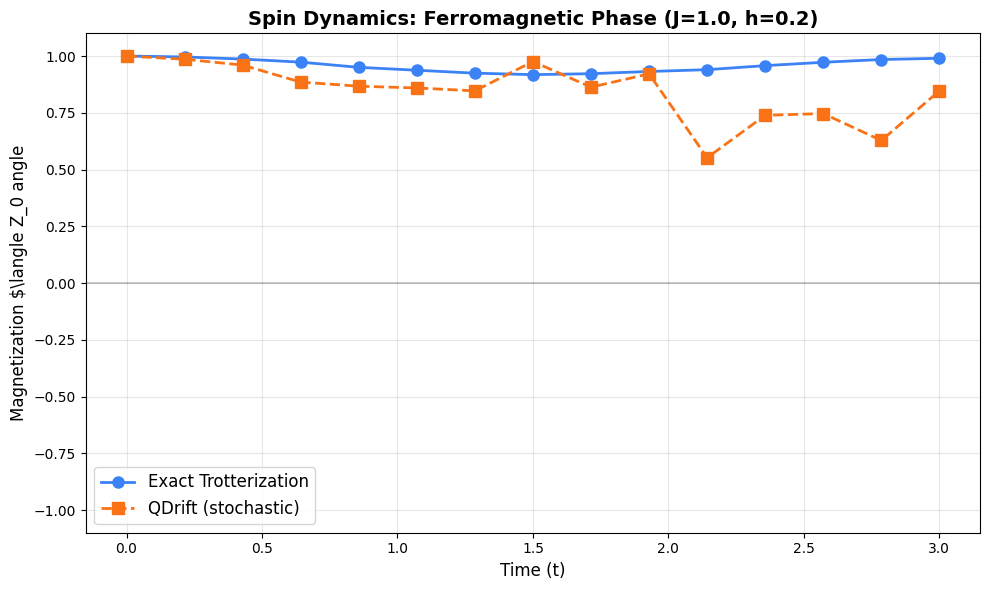

In [8]:
H_ferro = build_tfim_hamiltonian(n_qubits=N_QUBITS, J=1.0, h=0.2)

# Exact Trotterization
mag_exact_f = simulate_dynamics(H_ferro, times, ExactTrotterization(), backend, n_steps=N_STEPS)

# QDrift (restrict to sampling only 10 terms per Trotter step)
mag_qdrift_f = simulate_dynamics(H_ferro, times, QDrift(sampling_budget=10), backend, n_steps=N_STEPS)

plot_dynamics(times, mag_exact_f, mag_qdrift_f, "Spin Dynamics: Ferromagnetic Phase (J=1.0, h=0.2)")

## Experiment 2: Paramagnetic Phase ($h=2.0, J=1.0$)

When the transverse field is very strong ($h \gg J$), it overpowers the spin-spin coupling and causes the spins to precess rapidly strictly around the X-axis. This results in heavy oscillations in our measured $\langle Z_0 \rangle$.

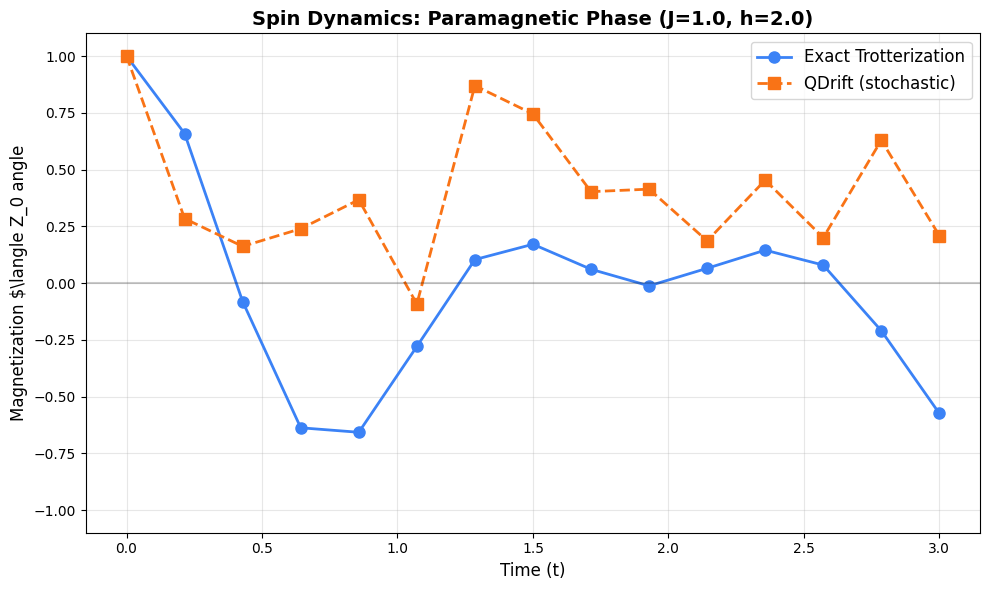

In [14]:
H_para = build_tfim_hamiltonian(n_qubits=N_QUBITS, J=1.0, h=2.0)

# Exact Trotterization
mag_exact_p = simulate_dynamics(H_para, times, ExactTrotterization(), backend, n_steps=N_STEPS)

# QDrift (restrict to 10 terms again)
mag_qdrift_p = simulate_dynamics(H_para, times, QDrift(sampling_budget=10), backend, n_steps=N_STEPS)

plot_dynamics(times, mag_exact_p, mag_qdrift_p, "Spin Dynamics: Paramagnetic Phase (J=1.0, h=2.0)")

## Experiment 3: Néel State Dynamics (Anti-ferromagnetic |101010>)

Divi's `TimeEvolution` also lets us supply arbitrary computational basis state strings for the initial state. Here we initialize the system in an alternating **Néel state**.

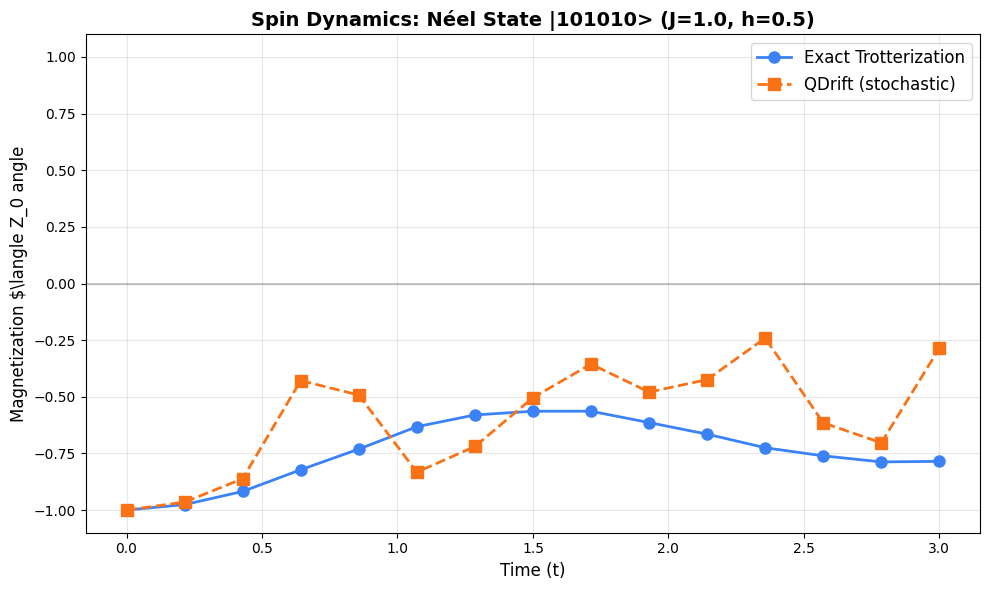

In [ ]:
H_neel = build_tfim_hamiltonian(n_qubits=N_QUBITS, J=1.0, h=0.5)

neel_state = "101010"

# Exact Trotterization
mag_exact_n = simulate_dynamics(H_neel, times, ExactTrotterization(), backend, n_steps=N_STEPS, initial_state=neel_state)

# QDrift (restrict to sampling only 10 terms per Trotter step)
mag_qdrift_n = simulate_dynamics(H_neel, times, QDrift(sampling_budget=10), backend, n_steps=N_STEPS, initial_state=neel_state)

plot_dynamics(times, mag_exact_n, mag_qdrift_n, "Spin Dynamics: Néel State |101010> (J=1.0, h=0.5)")